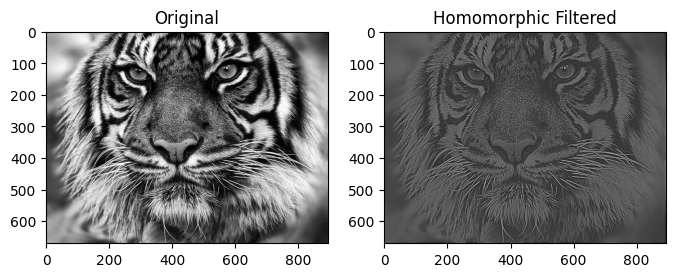

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read grayscale image
img = cv2.imread("image.jpg",0).astype(float)

# Normalize input
img = img/255.0

# Log transform
log_img = np.log1p(img)

# FFT
f = np.fft.fft2(log_img)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
crow, ccol = rows//2, cols//2

# Homomorphic parameters
D0 = 50
gammaL = 0.5
gammaH = 2

# Create filter
H = np.zeros((rows,cols))

for i in range(rows):
    for j in range(cols):
        D = np.sqrt((i-crow)**2 + (j-ccol)**2)
        H[i,j] = (gammaH-gammaL)*(1-np.exp(-(D**2)/(2*(D0**2)))) + gammaL

# Apply filter
filtered = fshift * H

# Inverse FFT
ishift = np.fft.ifftshift(filtered)
img_back = np.fft.ifft2(ishift)

# Exponential transform
exp_img = np.exp(np.real(img_back)) - 1

# Normalize to display
exp_img = cv2.normalize(exp_img, None, 0, 1, cv2.NORM_MINMAX)

# Display
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Homomorphic Filtered")
plt.imshow(exp_img, cmap='gray')

plt.show()